# eDNA Metabarcoding Pipeline Analysis: Lake Geneva
### A Reproducible Workflow for MinION Amplicon Sequencing (18S & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Marker:** 18S rRNA (Eukaryotic Biodiversity) & COI (Metazoan Target)

## 0. Critical Review: Limitations & Technical Constraints

Before presenting the biological results, I want to be honest about the technical limitations I encountered during this project. 
### 1. The COI Failure: Short Reads and Biological Swamping
While the 18S marker was successful, the COI marker did not perform as expected. 
* **Data Loss:** After pre-processing, I realized that over 90 percent of the raw COI reads were shorter than 300 base pairs. These are likely primer dimers or highly degraded DNA fragments. My pipeline correctly filtered these out to maintain data quality, but it left me with very few reads to analyze.
* **Lack of Specificity:** The few COI sequences that remained were mostly identified as ciliates rather than vertebrates. I believe ciliate DNA is so abundant in lake water that it effectively swamped the primers, preventing them from catching the rarer fish DNA we were looking for.

### 2. Taxonomic Gaps and the Choice of Accuracy
There are two reasons why the taxonomic results might look "imperfect" at first glance:
* **The Brazilian Bee Effect:** You will see assignments for exotic species like *Frieseomelitta* (a Brazilian bee) or *Gluvia* (an Iberian spider). This is a known database gap. The SILVA database lacks many local Swiss terrestrial sequences, so the algorithm simply identifies the closest genetic relative it can find.
* **The Unassigned Rate:** I deliberately kept a high confidence threshold of 0.8 for all assignments. While this results in many "Unassigned" rows at the species level, I believe it is better to be conservative. I would rather label a sequence as unknown than provide a false identification for a species that is not actually present in the lake.

### 3. Clustering and Size Selection Logic
I made specific decisions during the bioinformatic processing to ensure the results remained robust:
* **95 Percent Identity:** Because Nanopore sequencing has a raw error rate of around 5 percent, I clustered the sequences at 95 percent identity. If I had used a stricter threshold (like 99 percent), the sequencing errors would have been interpreted as thousands of "fake" new species.
* **The 18S Size Filter:** I discarded all 18S reads longer than 3000 base pairs. Since our target region is approximately 1800 base pairs, anything much longer is usually a concatemer (two DNA molecules fused together during library preparation). Including them would have artificially inflated the abundance counts for certain taxa.

### 4. Computational and Database Needs
The Global Clustering step was the primary bottleneck, taking up over 50 percent of the total runtime. With current data, it took around ~40 minutes to process the full pipeline.

## To-Do List for Future Work
I think there is still a lot of work to do to make this pipeline truly robust for lake monitoring. If I were to continue this project next semester, here are the specific improvements I would focus on:

* **Troubleshoot the COI yield:** I want to look into why 90 percent of the COI reads were too short. I suspect this is a PCR artifact but maybe we can play with parameters in the pipeline (size selection, etc.).
* **Design blocking primers:** Since my BLAST results showed that ciliates were the main competitor for the COI primers, lab team could implement a blocking primer. This would specifically target ciliate DNA and prevent it from amplifying, which would give rare fish or mussel DNA a better chance to be detected.
* **Create a local reference library:** I need to build a custom database for the lake. By gathering sequences for local fish, insects, and plants from NCBI, I could avoid the "Brazilian Bee" artifacts and get much more accurate species identifications.
* **Improve the clustering efficiency:** I would add a dereplication step before the global clustering. This would group identical sequences together early on, which would save a lot of time during the VSEARCH step and allow the pipeline to handle more samples at once.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,        
    'savefig.dpi': 300,       
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Define a function to clean sample names (e.g., "Sample_barcode01" -> "01")
def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

# Part A: 18S Marker Biodiversity Analysis
*Objective: To characterize the planktonic community structure and validate the bioinformatic pipeline using the 18S marker.*

## A.1.a Broad Taxonomic Structure
This stacked bar chart visualizes the relative abundance of eukaryotic Phyla across all samples.
* **Expected Result:** We expect to see high abundances of **Arthropoda** (Zooplankton) and **Ciliophora** (Microbial Loop).
* **Terrestrial Input:** Look for **Phragmoplastophyta** (Land Plants/Pollen).

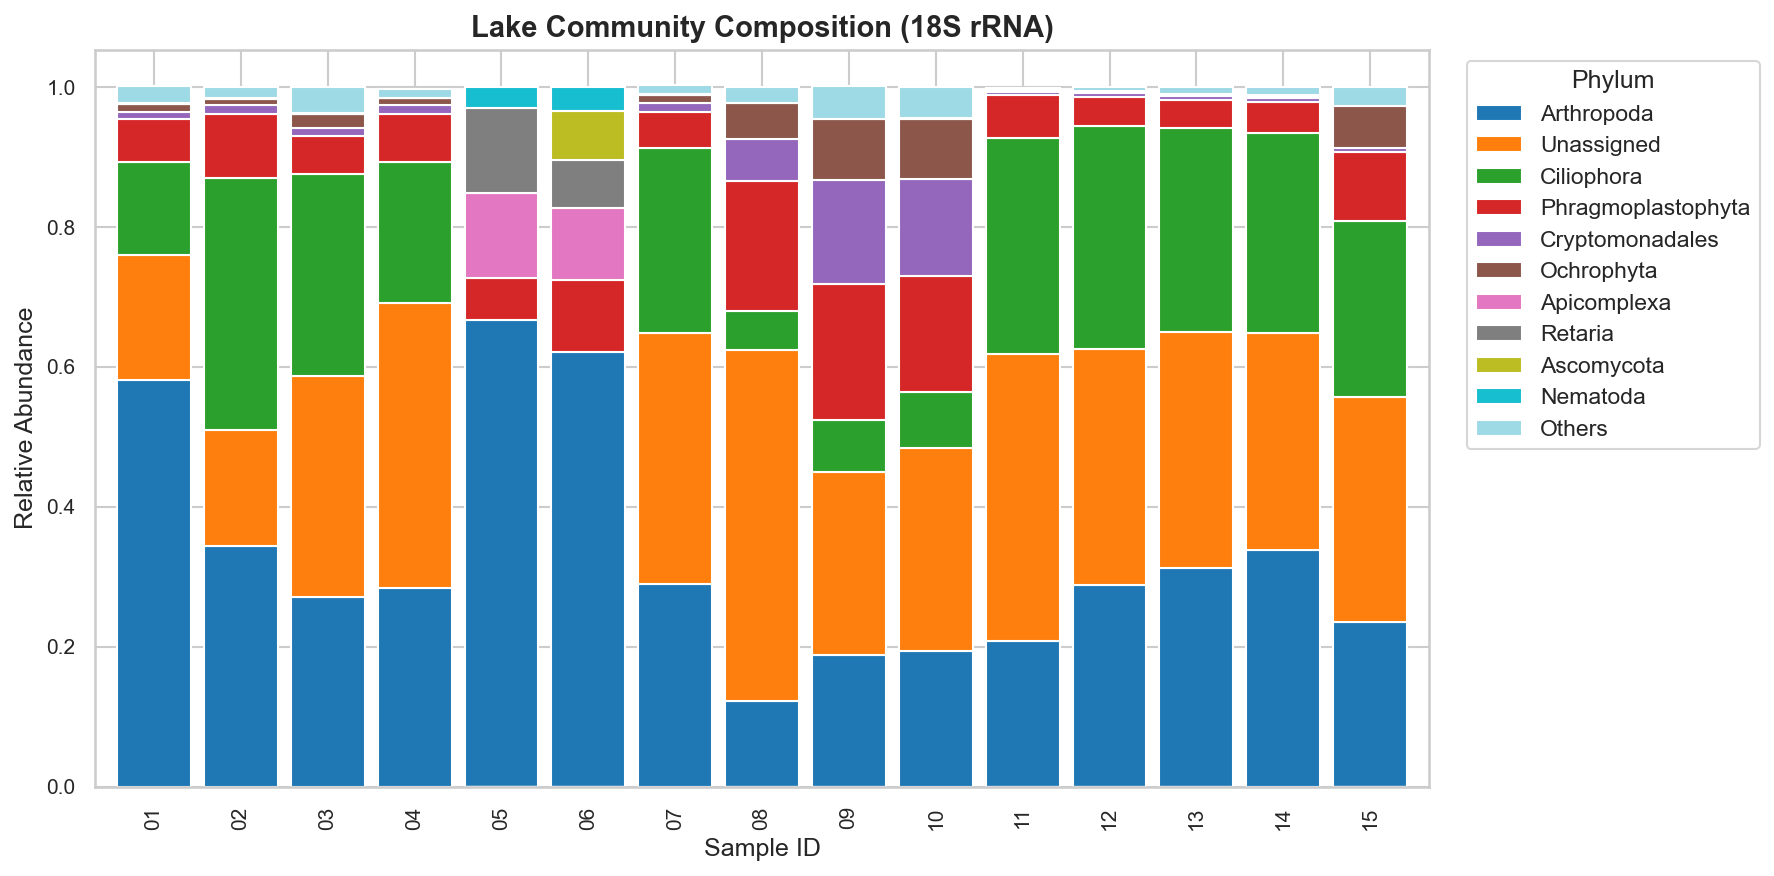

In [15]:
# Load 18S Data
df_18s = pd.read_csv('out/Water_eDNA_18S_COI_14_01_26/taxonomy_summary/comprehensive_taxonomy_18S.csv')
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]

# Group by Phylum
df_18s['SILVA_Phylum'] = df_18s['SILVA_Phylum'].fillna('Unassigned')
phylum_18s = df_18s.groupby('SILVA_Phylum')[sample_cols_18s].sum()

# Sort and Group "Others"
phylum_18s['Total'] = phylum_18s.sum(axis=1)
phylum_18s = phylum_18s.sort_values('Total', ascending=False)
top_phyla = phylum_18s.head(10).index

plot_data = phylum_18s.loc[top_phyla].drop(columns='Total')
others = phylum_18s.loc[~phylum_18s.index.isin(top_phyla)].drop(columns='Total').sum()
plot_data.loc['Others'] = others

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data.columns = clean_sample_names(plot_data.columns)
plot_data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title('Lake Community Composition (18S rRNA)', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## A.1.b Family-Level Breakdown (18S)
**Objective:** To see which specific biological families dominate within the broad Phyla.

**Visual Analysis:**
1.  **Oligotrichia (Microbial Loop):** The dominant *identified* family is likely **Oligotrichia** (or *Strobilidiidae*). This confirms that Ciliates are the most abundant eukaryotes in our samples.
2.  **The "Unassigned" Gap (Hidden Insects):** You will notice a large "Unassigned" component. In the Phylum plot, we saw a massive "Arthropod" signal (Insects/Spiders). Here, those reads likely fall into "Unassigned" because the database lacks Family-level resolution for these terrestrial inputs.
3.  **Daphniidae (Zooplankton Validation):** Check the legend for **Daphniidae**. Even if the bar is small compared to the Ciliates, its distinct presence validates that the pipeline successfully detected the target aquatic zooplankton.

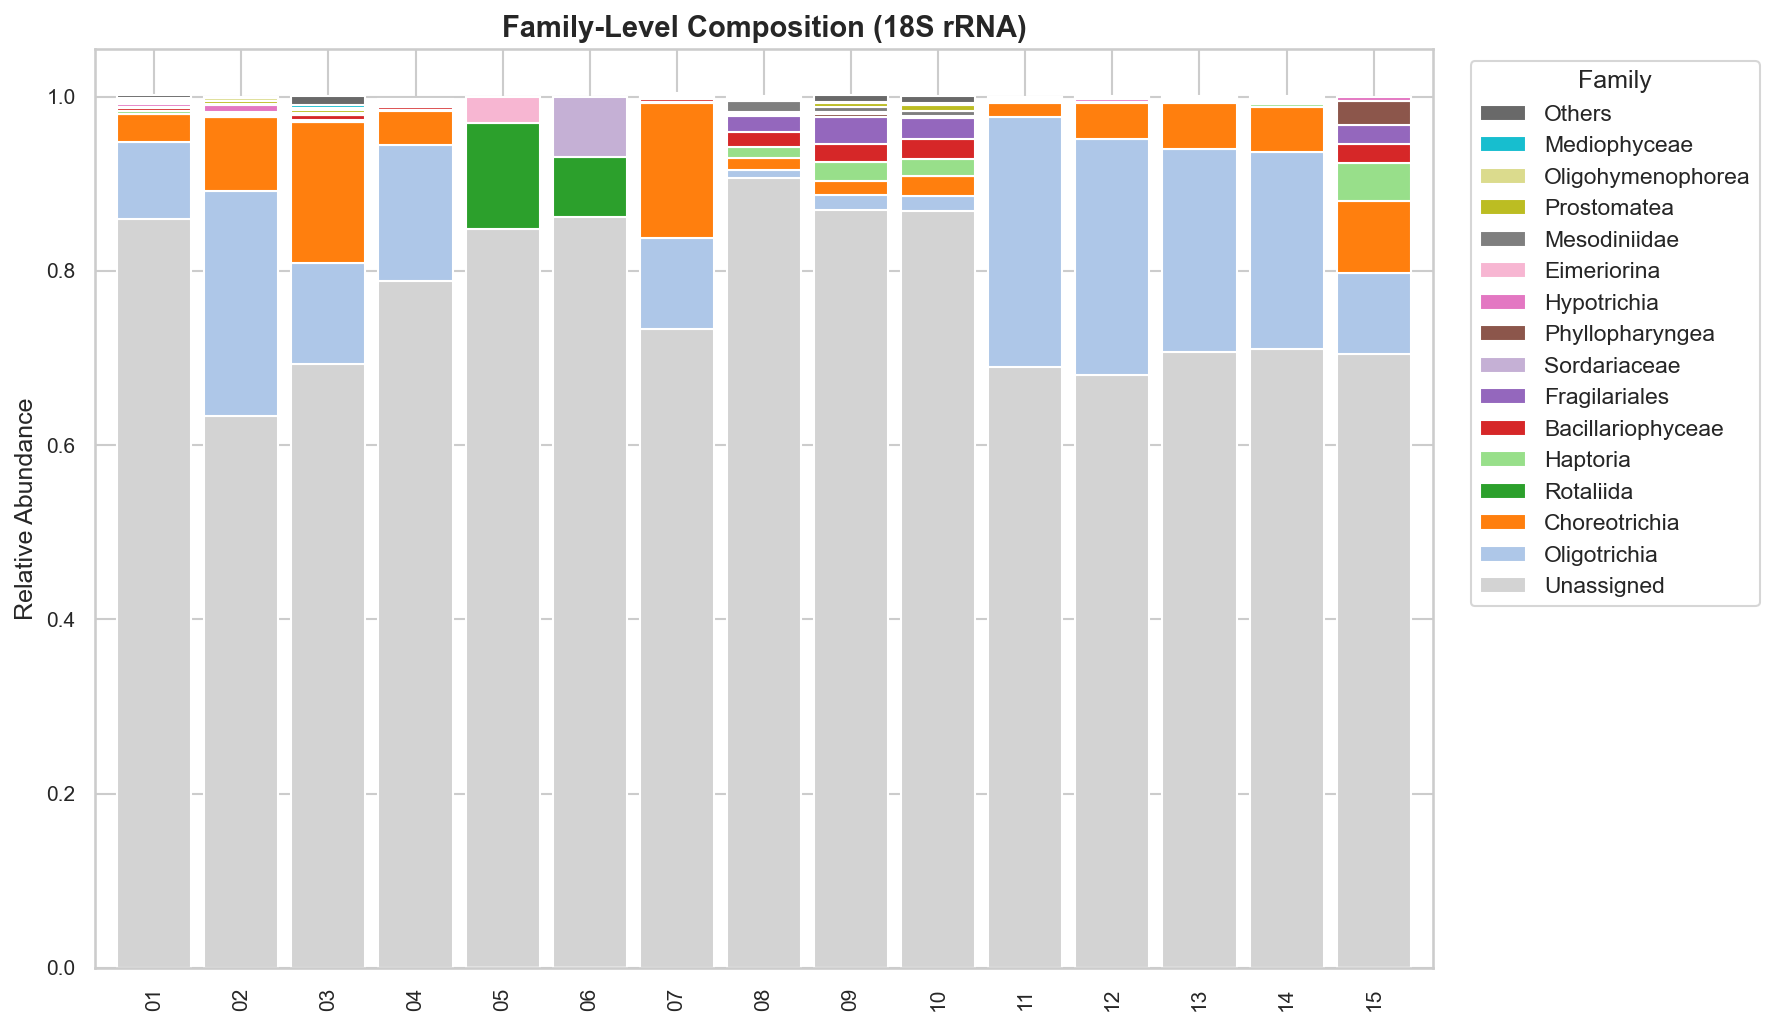

In [16]:
# Group by Family (18S)
from matplotlib import cm

df_18s['SILVA_Family'] = df_18s['SILVA_Family'].fillna('Unassigned')
family_18s = df_18s.groupby('SILVA_Family')[sample_cols_18s].sum()

# Sort and Top 15
family_18s['Total'] = family_18s.sum(axis=1)
family_18s = family_18s.sort_values('Total', ascending=False)
top_families = family_18s.head(15).index

# Prepare Data
plot_fam = family_18s.loc[top_families].drop(columns='Total')
others_fam = family_18s.loc[~family_18s.index.isin(top_families)].drop(columns='Total').sum()
plot_fam.loc['Others'] = others_fam

# --- CUSTOM COLOR LOGIC START ---
# Create a color map that maps specific Families to specific colors
# 1. Generate enough colors for all families from a vibrant palette (e.g., tab20)
num_colors = len(plot_fam)
colors = cm.tab20(np.linspace(0, 1, num_colors))

# 2. Create a specific list of colors matching the order of your DataFrame rows
custom_colors = []
for i, family_name in enumerate(plot_fam.index):
    if family_name == 'Unassigned':
        custom_colors.append('#D3D3D3')  # Light Grey for Unassigned
    elif family_name == 'Others':
        custom_colors.append('#696969')  # Dark Grey for Others
    else:
        custom_colors.append(colors[i])  # Standard color for biological families

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_fam.columns = clean_sample_names(plot_fam.columns)

# Pass the custom_colors list to the color argument
plot_fam.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors)

ax.set_title('Family-Level Composition (18S rRNA)', fontweight='bold')
ax.set_ylabel('Relative Abundance')
# Reverse legend order so it matches the stack order visually
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Family')

plt.tight_layout()
plt.show()

## A.2 Dominant Taxa: Genus Level Analysis
**Question:** Which specific organisms are driving the biological signal?

Here we check if our "Arthropod" signal is actually **Zooplankton** (good) or just **Insects** (contamination/pollen).
* **Key Targets:** We look for ***Strombidium*** (Ciliates) and ***Daphnia*** (Water Fleas).

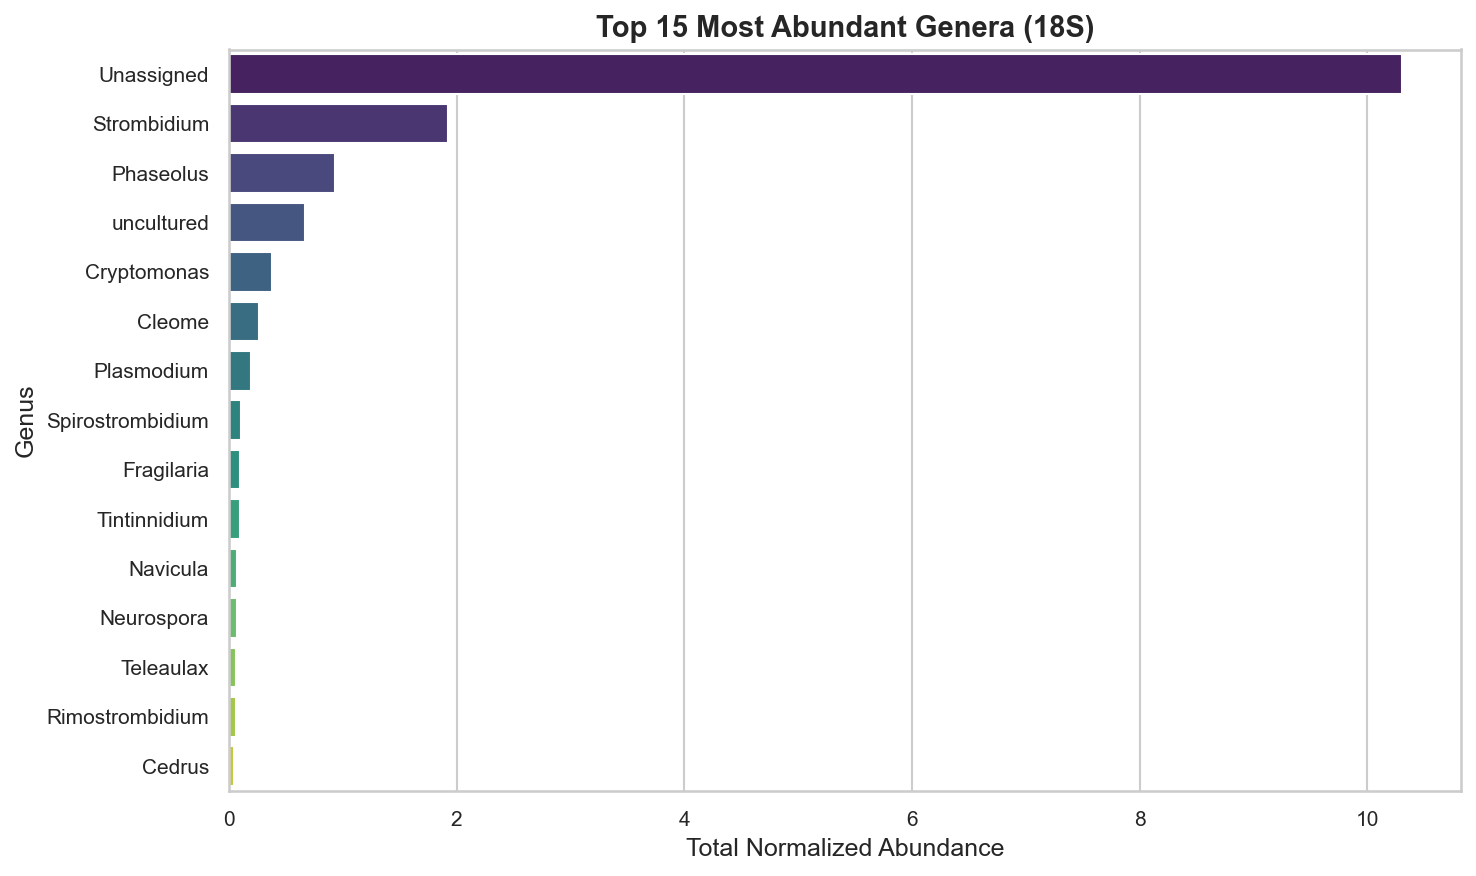

In [17]:
# Group by Genus
df_18s['SILVA_Genus'] = df_18s['SILVA_Genus'].fillna('Unassigned')
genus_18s = df_18s.groupby('SILVA_Genus')['Total_Abundance'].sum().sort_values(ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genus_18s.values, y=genus_18s.index, hue=genus_18s.index, palette="viridis", ax=ax, legend=False)

ax.set_title('Top 15 Most Abundant Genera (18S)', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Genus')

plt.tight_layout()
plt.show()

## A.3 Detailed Identification: Top 20 Species
**Objective:** To get the most granular identification possible (Species Level).

**Why is "Unassigned" the top hit?**
You will notice the top category is "Unassigned." This represents sequences where the algorithm could identify the *Genus* (e.g., Strombidium) but could not confidently name the specific *Species*. This is common in microbial datasets where many species have never been sequenced before.

**Key Biological Finds (excluding Unassigned):**
* **"Daphnia pulex":** Validates the zooplankton signal.
* **"Gluvia dorsalis":** Represents the local spider/insect signal (database limitation).
* **"Phaseolus":** Confirms the presence of plant DNA (pollen/runoff).

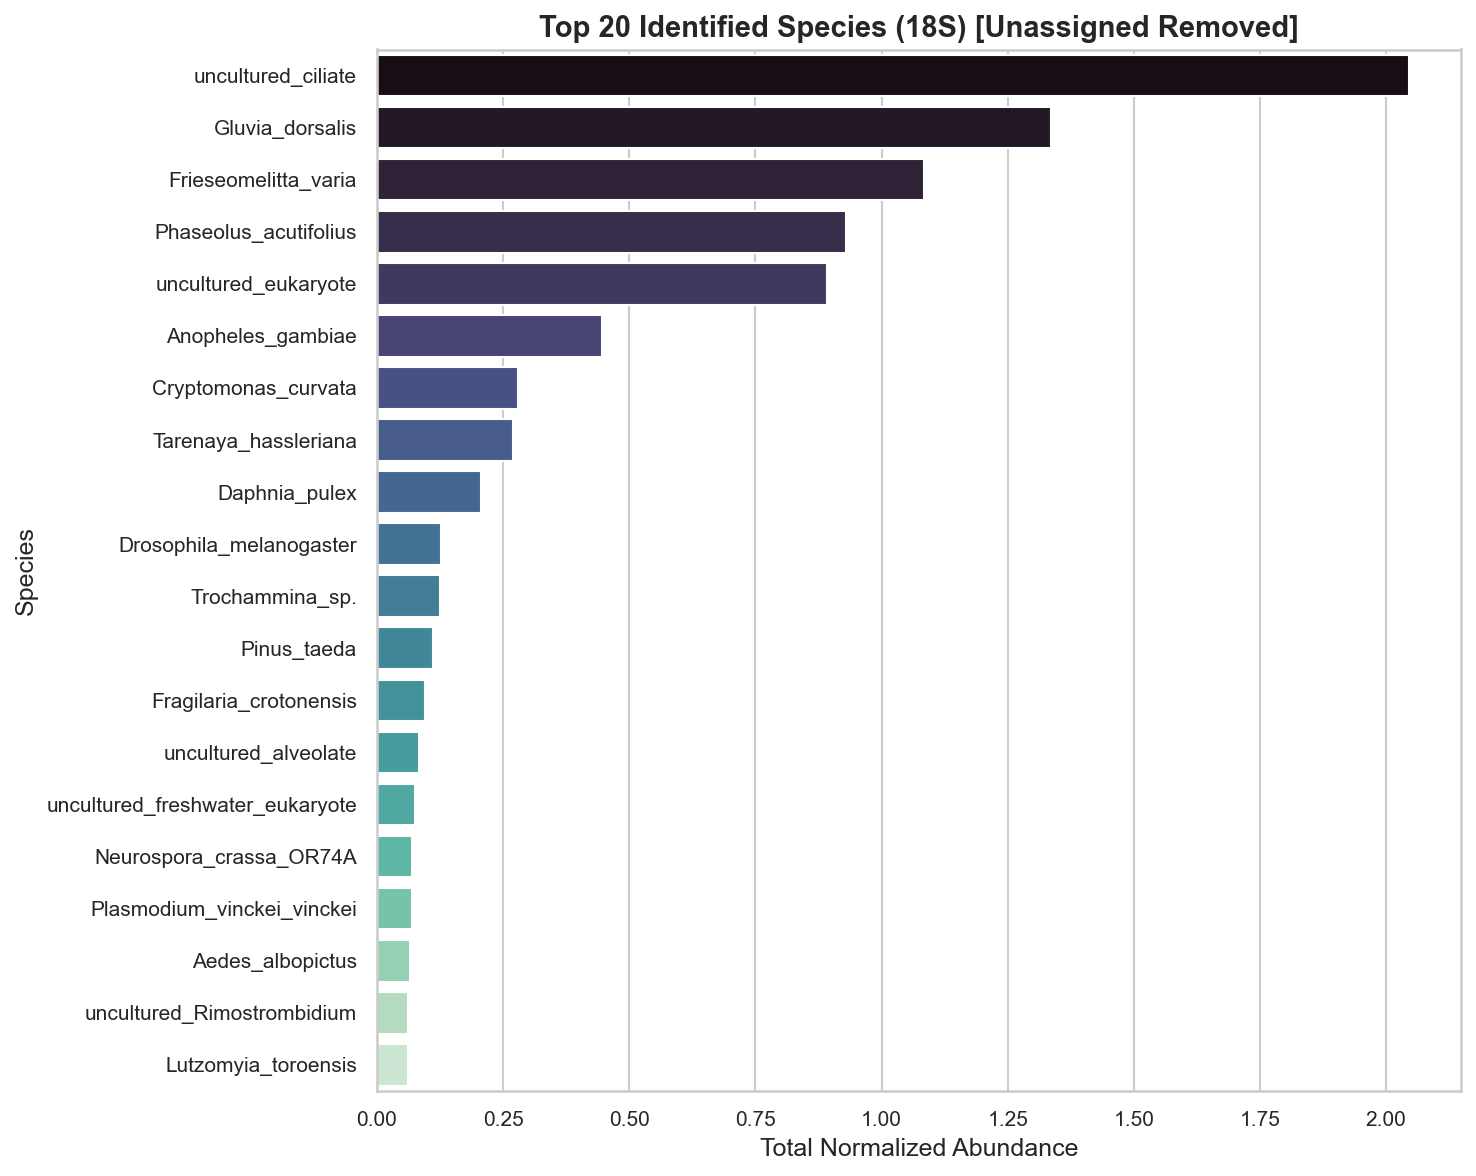

In [18]:
# 1. Group by Species
df_18s['SILVA_Species'] = df_18s['SILVA_Species'].fillna('Unassigned')

# Sum abundance
species_18s = df_18s.groupby('SILVA_Species')['Total_Abundance'].sum()

# Sort
species_18s = species_18s.sort_values(ascending=False)

# FILTER: Remove 'Unassigned' to focus on identified species
species_18s_clean = species_18s.drop('Unassigned', errors='ignore').head(20)

# 2. Plotting
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=species_18s_clean.values, y=species_18s_clean.index, hue=species_18s_clean.index, palette="mako", ax=ax, legend=False)

ax.set_title('Top 20 Identified Species (18S) [Unassigned Removed]', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Species')

plt.tight_layout()
plt.show()

### Interpretation of 18S Results:
1.  **Success:** The pipeline successfully recovered the core lake community.
2.  **Microbial Loop:** The dominance of ***Strombidium*** (the top bar above) confirms a highly active microbial food web.
3.  **Zooplankton:** ***Daphnia*** is among the top genera, validating that our sampling method captures metazoans.
4.  **The "Artifacts":** The presence of *Frieseomelitta* (Bee) and *Gluvia* (Spider) confirms the terrestrial DNA inputs mentioned in the limitations.

## A.4 The "Unassigned" Reality Check
**Limitation:** A significant portion of reads (especially at the family level) remain "Unassigned."

**Why does this happen?**
1.  **Database Gaps:** The SILVA database is excellent but not exhaustive.
2.  **Strict Thresholds:** We used a **confidence threshold of 0.8** in SINTAX. If the algorithm is not sure, it marks it as "Unassigned" rather than guessing wrong.
3.  **Methodological Choice:** We chose **Accuracy over Coverage**. We prefer to say "Unknown Ciliate" than to falsely identify it as a species that doesn't exist here. _**But it should definitely be investigated further in future work.**_

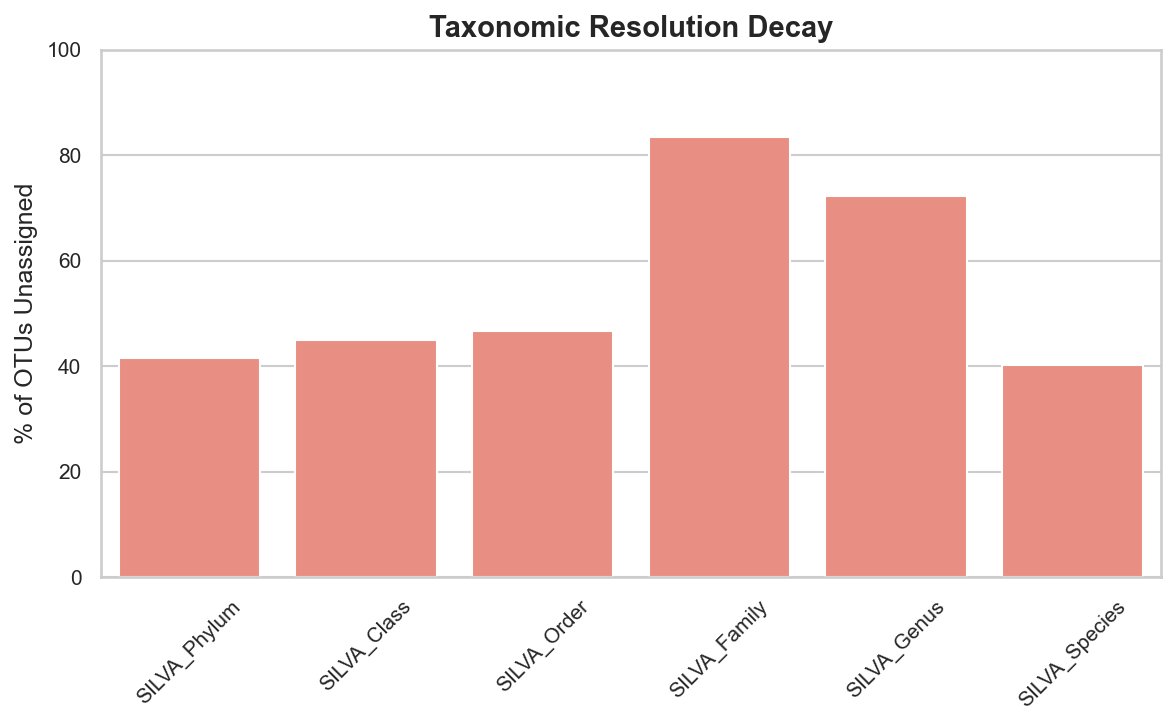

In [19]:
# Calculate % Unassigned at each level
levels = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']
unassigned_counts = []

for level in levels:
    # Count how many rows are NaN or 'Unassigned'
    n_unassigned = df_18s[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_counts.append(pct)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=levels, y=unassigned_counts, color="salmon")
plt.title('Taxonomic Resolution Decay', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## A.5 Forensics: Manual BLAST Identification (18S)
BLAST validation of the top 18S OTUs provides ground-truth identification beyond what SINTAX can offer.
1. **Ciliate Confirmation:** We expect the top OTUs to be confirmed as uncultured ciliate clones, consistent with the SINTAX results.
2. **Daphnia Validation:** Look for *Daphnia galeata* — its presence via BLAST confirms the zooplankton signal seen in the genus-level analysis.
3. **Uncultured Eukaryotes:** Many top hits may be "Uncultured eukaryote clone," reflecting organisms not yet formally described in databases.

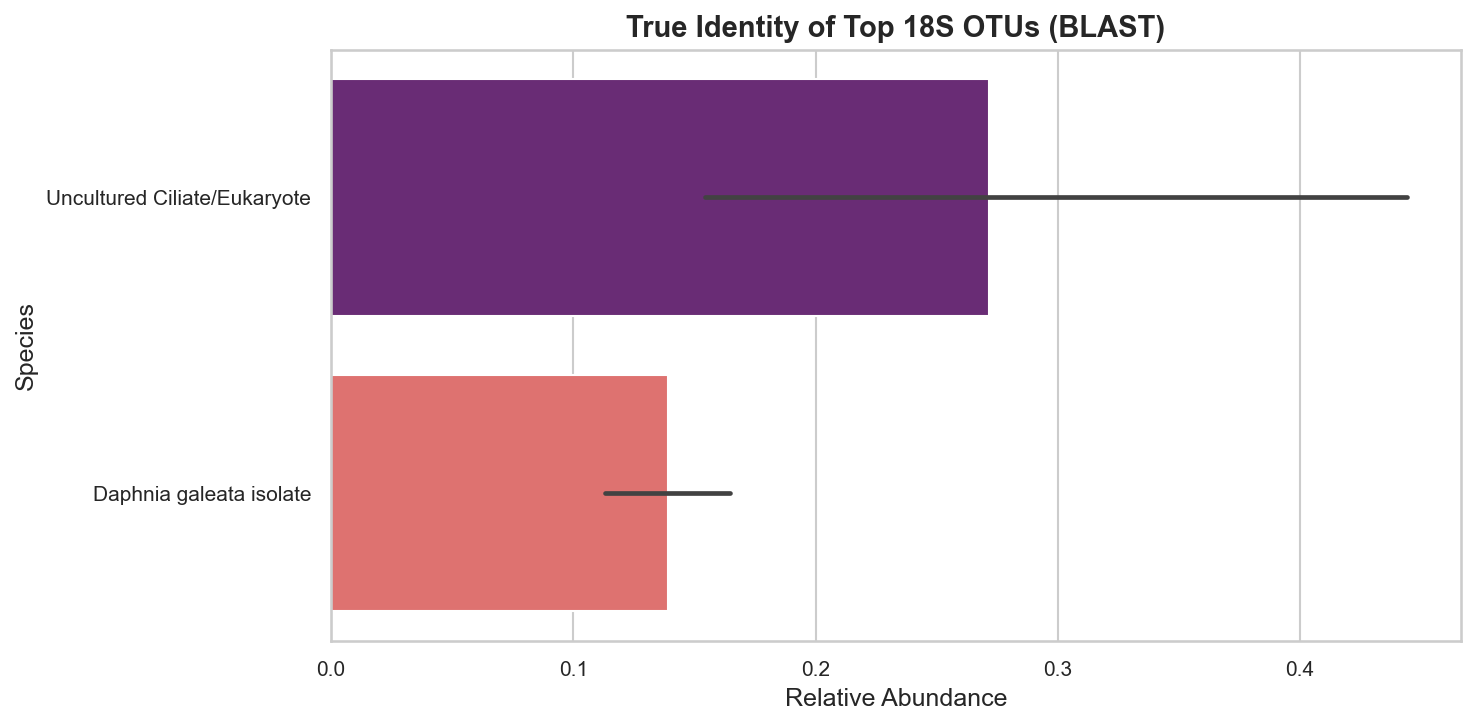

In [20]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        # skip header
        start_reading = False
        for line in lines:
            if line.startswith('---'): 
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            
            parts = line.split('|')
            if len(parts) >= 3:
                # Extract clean species name
                species = parts[2].strip()
                # Clean up "Uncultured..." names for better plotting
                if "Uncultured" in species: species = "Uncultured Ciliate/Eukaryote"
                
                try:
                    reads = float(parts[1].strip())
                    data.append({'Species': species, 'Abundance': reads})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
        
    return pd.DataFrame(data)

# Load and Plot 18S BLAST results
df_blast_18s = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_18S.txt')

if not df_blast_18s.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_blast_18s, y='Species', x='Abundance', hue='Species', palette='magma', legend=False)
    plt.title('True Identity of Top 18S OTUs (BLAST)', fontweight='bold')
    plt.xlabel('Relative Abundance')
    plt.tight_layout()
    plt.show()
else:
    print("No valid 18S BLAST data found to plot.")

# Part B: COI Marker Biodiversity Analysis
*Objective: To characterize the metazoan community structure using the COI marker and investigate why it failed to detect the expected vertebrate (Fish) signals.*

**Technical Context:** A MIDORI2 COI reference database was used for SINTAX-based taxonomy assignment (vs. SILVA for 18S). Key differences between the databases:
* **Taxonomy format:** MIDORI2 appends NCBI taxon IDs to names (e.g., `Arthropoda_6656`) and uses rank prefixes (e.g., `phylum_Cryptophyceae`) — these are cleaned below.
* **Species resolution:** MIDORI2's SINTAX output provides only genus-level names in the species field (e.g., `s:Cyclops`) — 99.9% of COI "species" are identical to genus. True species-level identification requires BLAST.
* **Domain field:** MIDORI2 uses `k:` (kingdom) instead of `d:` (domain), so the `SILVA_Domain` column is empty for COI in the current pipeline output.
* Many assignments fell below the 0.8 confidence threshold, and only ~65% of OTUs received any taxonomy.

## B.1.a Broad Taxonomic Structure (COI)
This stacked bar chart visualizes the relative abundance of Phyla across all samples using the COI marker.
* **Expected Result:** If the COI primers worked well, we would expect to see **Chordata** (Fish) and **Arthropoda** (Invertebrates).
* **Reality Check:** Due to ciliate swamping and short-read issues, the actual composition may differ significantly from expectations.

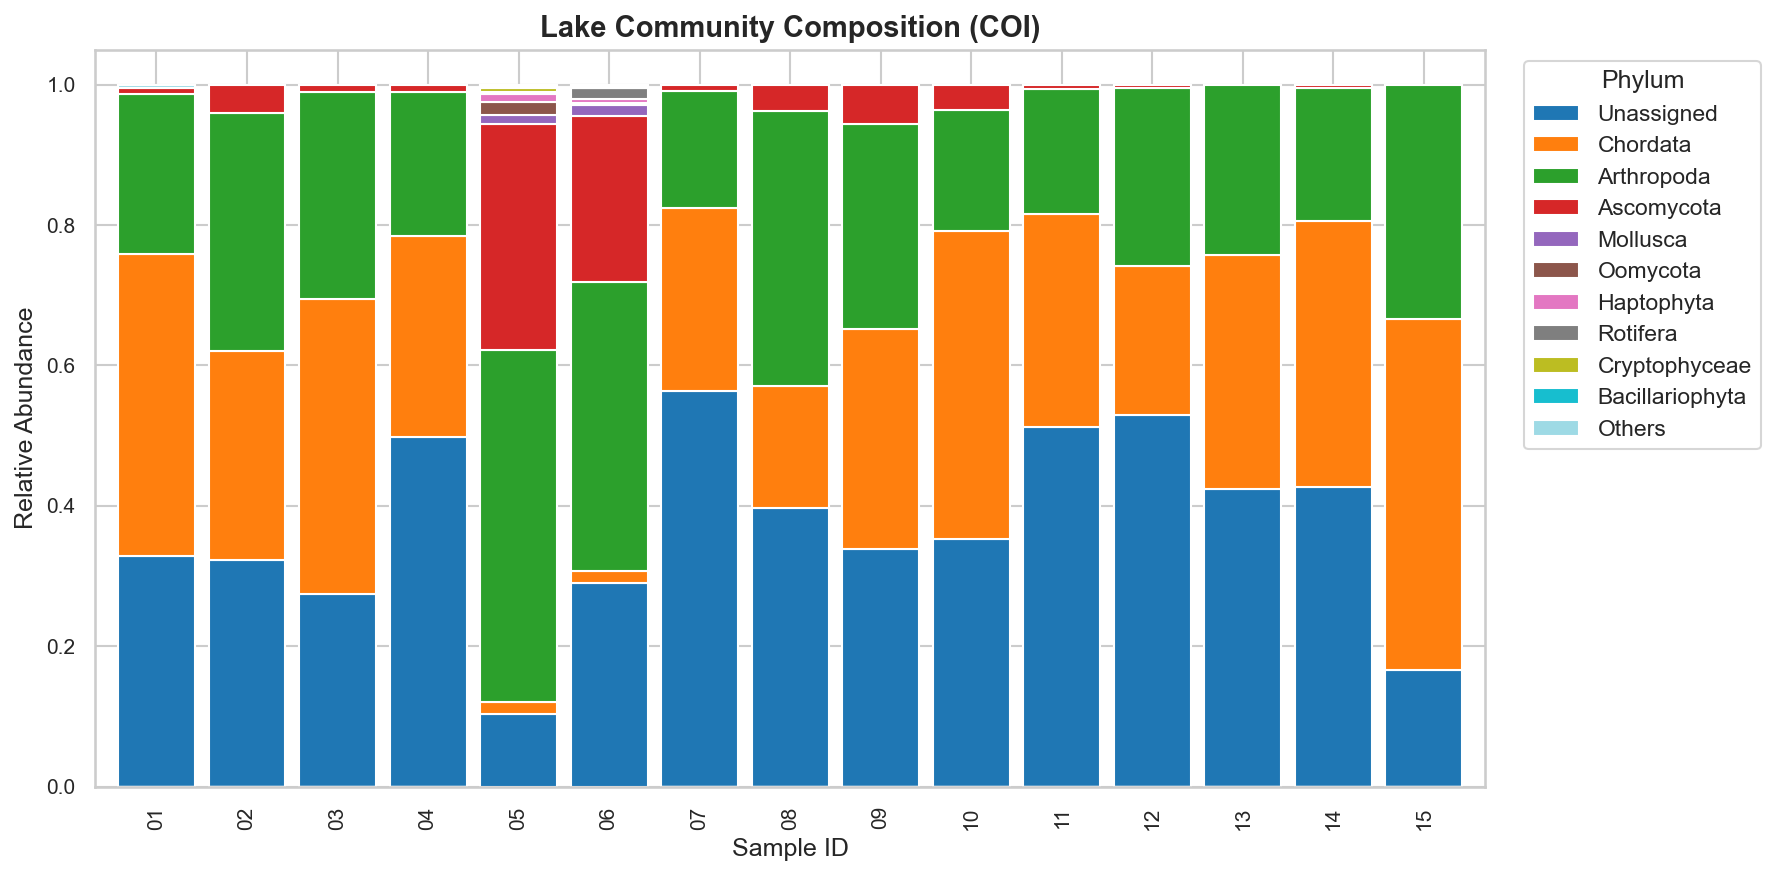

In [21]:
# Load COI Data
import re

df_coi = pd.read_csv('out/Water_eDNA_18S_COI_14_01_26/taxonomy_summary/comprehensive_taxonomy_COI.csv')
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]

# Clean taxonomy labels:
#  1. Strip rank prefixes like "phylum_", "order_" (e.g., "phylum_Cryptophyceae_3027" -> "Cryptophyceae_3027")
#  2. Remove trailing NCBI taxon IDs (e.g., "Arthropoda_6656" -> "Arthropoda")
rank_prefixes = re.compile(r'^(kingdom|phylum|class|order|family|genus|species)_', re.IGNORECASE)
tax_levels = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']
for col in tax_levels:
    if col in df_coi.columns:
        df_coi[col] = df_coi[col].apply(
            lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
        )
        df_coi[col] = df_coi[col].apply(
            lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
            if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
            else x
        )

# Group by Phylum
df_coi['SILVA_Phylum'] = df_coi['SILVA_Phylum'].fillna('Unassigned')
phylum_coi = df_coi.groupby('SILVA_Phylum')[sample_cols_coi].sum()

# Sort and Group "Others"
phylum_coi['Total'] = phylum_coi.sum(axis=1)
phylum_coi = phylum_coi.sort_values('Total', ascending=False)
top_phyla_coi = phylum_coi.head(10).index

plot_data_coi = phylum_coi.loc[top_phyla_coi].drop(columns='Total')
others_coi = phylum_coi.loc[~phylum_coi.index.isin(top_phyla_coi)].drop(columns='Total').sum()
plot_data_coi.loc['Others'] = others_coi

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data_coi.columns = clean_sample_names(plot_data_coi.columns)
plot_data_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title('Lake Community Composition (COI)', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## B.1.b Family-Level Breakdown (COI)
**Objective:** To see which specific biological families dominate within the broad Phyla for the COI marker.

**Visual Analysis:**
1. **Ciliate Families:** We expect to see ciliate-related families dominating, consistent with the "swamping" effect described earlier.
2. **Daphniidae:** Look for the presence of **Daphniidae** (Water Fleas) — this would confirm that the COI marker captured at least some target aquatic organisms.
3. **The "Unassigned" Gap:** Due to the lower taxonomy resolution with COI and the MIDORI2 database, we expect a significant "Unassigned" fraction.

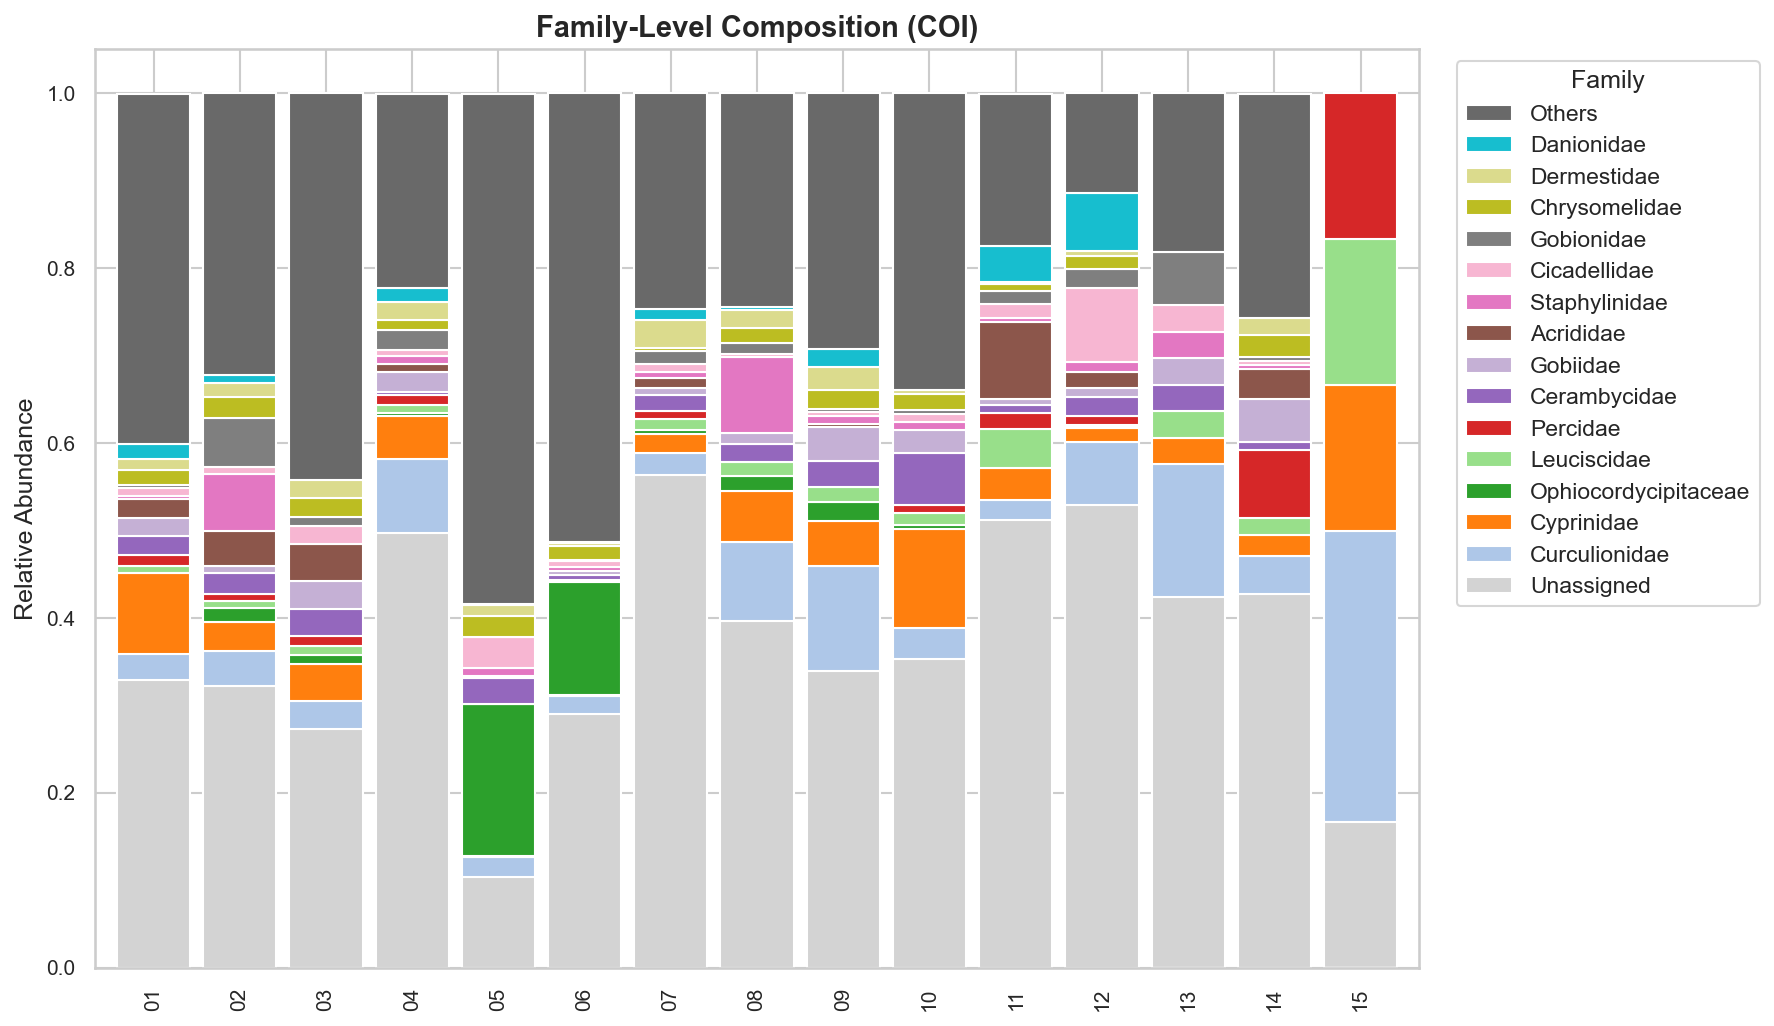

In [22]:
# Group by Family (COI)
df_coi['SILVA_Family'] = df_coi['SILVA_Family'].fillna('Unassigned')
family_coi = df_coi.groupby('SILVA_Family')[sample_cols_coi].sum()

# Sort and Top 15
family_coi['Total'] = family_coi.sum(axis=1)
family_coi = family_coi.sort_values('Total', ascending=False)
top_families_coi = family_coi.head(15).index

# Prepare Data
plot_fam_coi = family_coi.loc[top_families_coi].drop(columns='Total')
others_fam_coi = family_coi.loc[~family_coi.index.isin(top_families_coi)].drop(columns='Total').sum()
plot_fam_coi.loc['Others'] = others_fam_coi

# Custom color logic
num_colors_coi = len(plot_fam_coi)
colors_coi = cm.tab20(np.linspace(0, 1, num_colors_coi))

custom_colors_coi = []
for i, family_name in enumerate(plot_fam_coi.index):
    if family_name == 'Unassigned':
        custom_colors_coi.append('#D3D3D3')
    elif family_name == 'Others':
        custom_colors_coi.append('#696969')
    else:
        custom_colors_coi.append(colors_coi[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_fam_coi.columns = clean_sample_names(plot_fam_coi.columns)
plot_fam_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors_coi)

ax.set_title('Family-Level Composition (COI)', fontweight='bold')
ax.set_ylabel('Relative Abundance')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Family')

plt.tight_layout()
plt.show()

## B.2 Dominant Taxa: Genus Level Analysis (COI)
**Question:** Which specific organisms are driving the COI biological signal?

Unlike the 18S marker which captured a broad eukaryotic community, the COI marker should theoretically be more specific to metazoans. Here we check if any vertebrate or invertebrate genera were successfully captured.
* **Key Targets:** We look for ***Daphnia*** (Water Fleas) and any fish genera.
* **Expected Contaminants:** ***Ciliate*** genera that were non-specifically amplified.

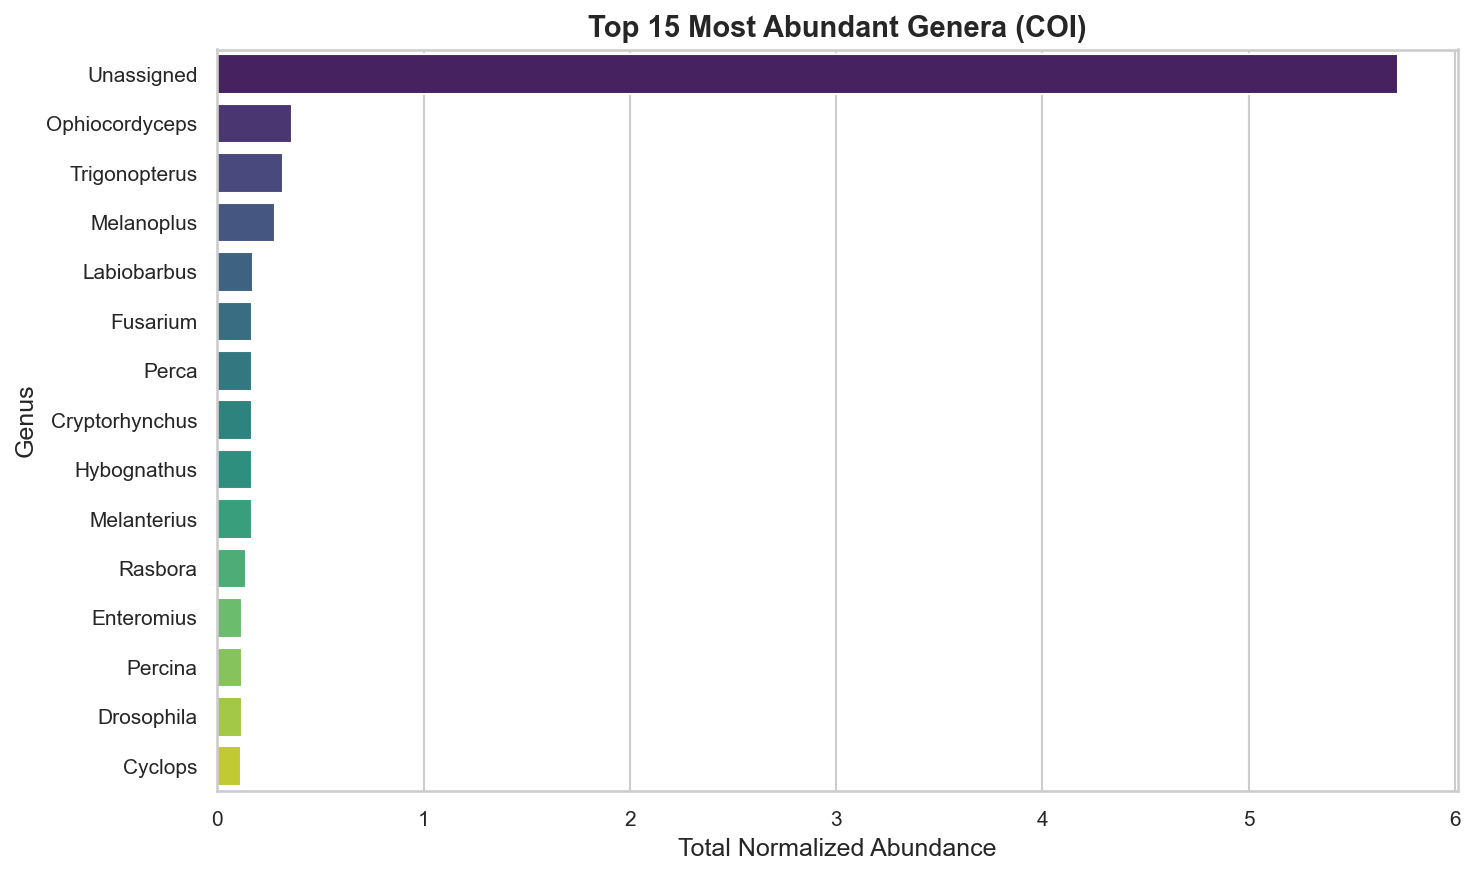

In [23]:
# Group by Genus (COI)
df_coi['SILVA_Genus'] = df_coi['SILVA_Genus'].fillna('Unassigned')
genus_coi = df_coi.groupby('SILVA_Genus')['Total_Abundance'].sum().sort_values(ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genus_coi.values, y=genus_coi.index, hue=genus_coi.index, palette="viridis", ax=ax, legend=False)

ax.set_title('Top 15 Most Abundant Genera (COI)', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Genus')

plt.tight_layout()
plt.show()

## B.3 Detailed Identification: Top 20 Species (COI)
**Objective:** To get the most granular identification possible at the Species level from the COI marker.

**MIDORI2 Limitation:** Unlike SILVA (which provides binomial species names like *Daphnia_pulex*), MIDORI2's SINTAX output only retains the **genus name** in the species field (e.g., `s:Cyclops`). In fact, 99.9% of COI "species" assignments are identical to their genus. This means the plot below is effectively a **genus-level** ranking. For true species-level identification, BLAST validation (Section B.5) is required.

**Why is "Unassigned" expected to dominate?**
1. Many MIDORI2 assignments fell below the 0.8 confidence threshold.
2. Only ~65% of COI OTUs received any taxonomy assignment at all.
3. The short-read filtering removed >90% of raw reads, leaving very few sequences for classification.

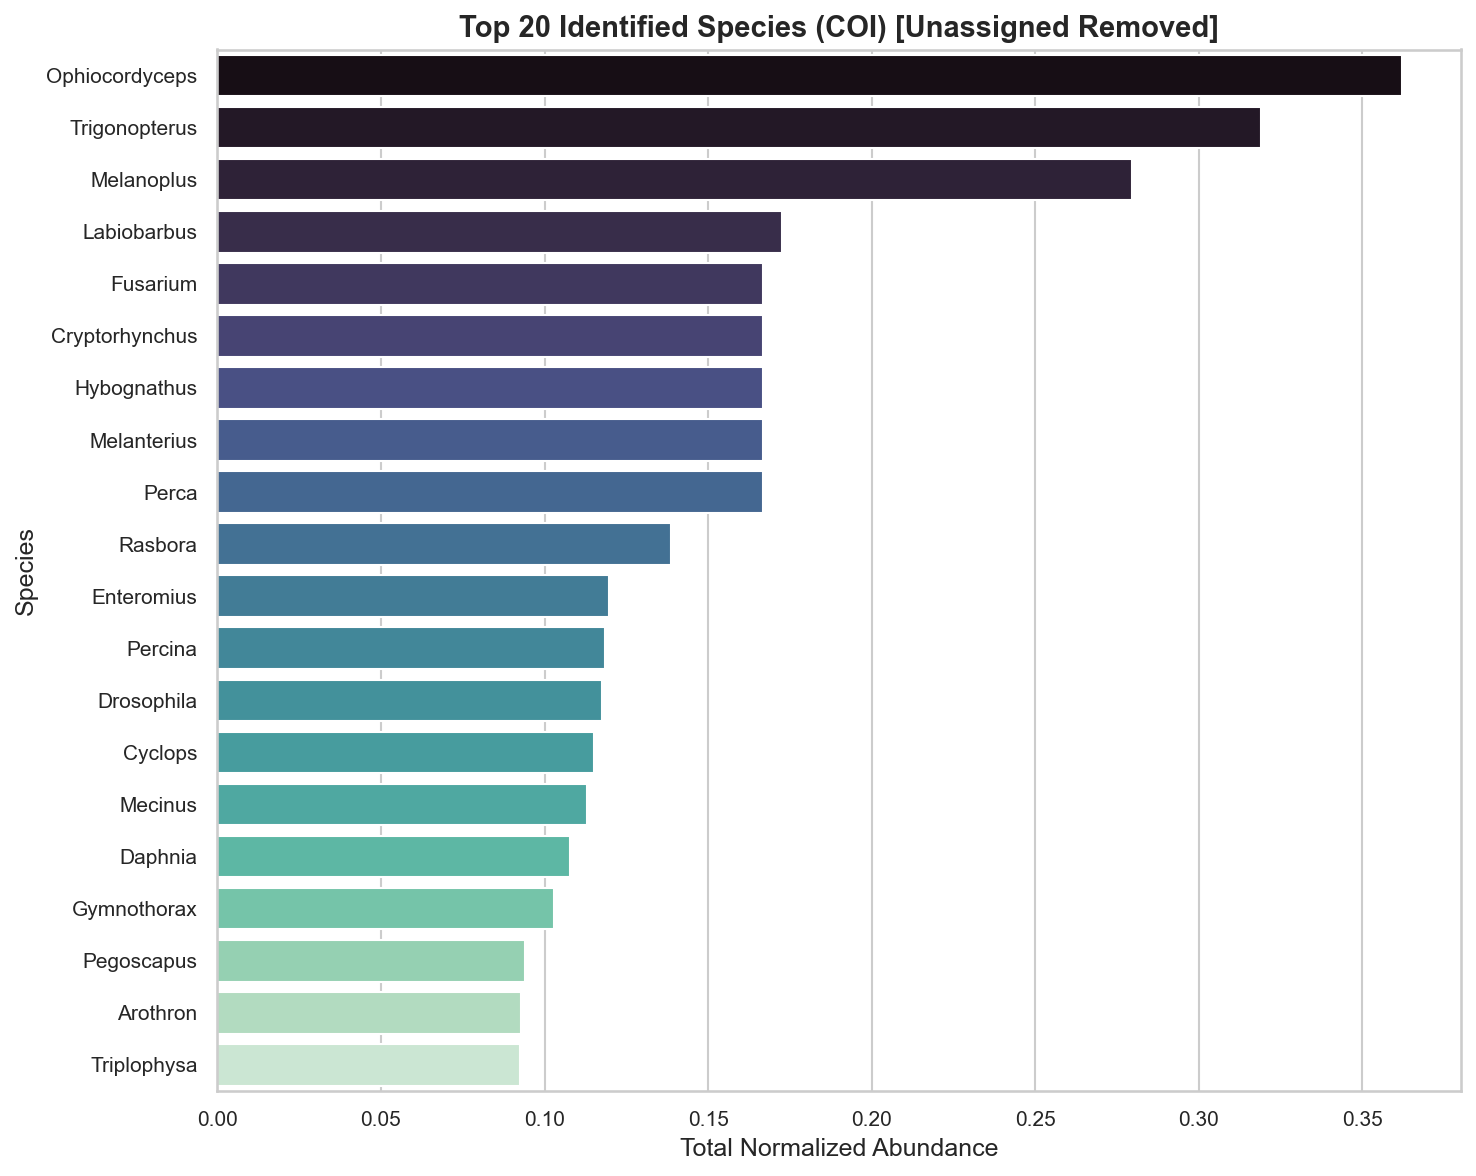

In [24]:
# Group by Species (COI)
df_coi['SILVA_Species'] = df_coi['SILVA_Species'].fillna('Unassigned')

# Sum abundance
species_coi = df_coi.groupby('SILVA_Species')['Total_Abundance'].sum()

# Sort
species_coi = species_coi.sort_values(ascending=False)

# FILTER: Remove 'Unassigned' to focus on identified species
species_coi_clean = species_coi.drop('Unassigned', errors='ignore').head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=species_coi_clean.values, y=species_coi_clean.index, hue=species_coi_clean.index, palette="mako", ax=ax, legend=False)

ax.set_title('Top 20 Identified Species (COI) [Unassigned Removed]', fontweight='bold')
ax.set_xlabel('Total Normalized Abundance')
ax.set_ylabel('Species')

plt.tight_layout()
plt.show()

## B.4 The "Unassigned" Reality Check (COI)
**Comparison with 18S:** We expect the COI marker to have a significantly higher "Unassigned" rate than 18S at every taxonomic level, due to the combination of:
1. Lower sequencing depth (after short-read filtering)
2. The strict 0.8 confidence threshold applied to SINTAX assignments
3. Potential database gaps in the MIDORI2 COI reference

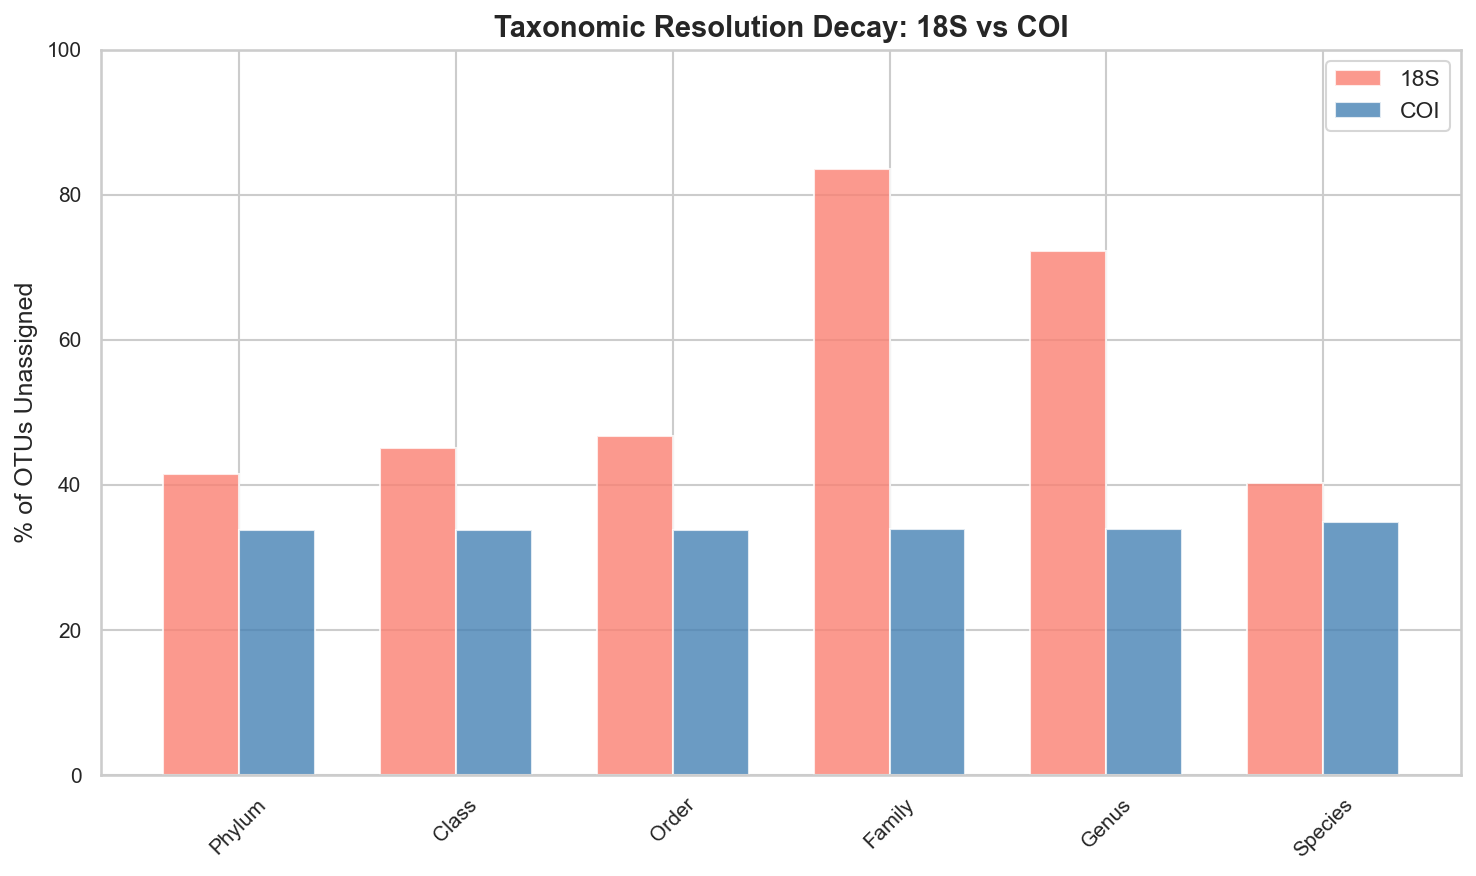

In [25]:
# Calculate % Unassigned at each level (COI)
levels_coi = ['SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species']
unassigned_counts_coi = []

for level in levels_coi:
    n_unassigned = df_coi[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_counts_coi.append(pct)

# Plot: side-by-side comparison with 18S
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(levels_coi))
width = 0.35

# Recalculate 18S unassigned for comparison
unassigned_18s = []
for level in levels_coi:
    n_unassigned = df_18s[level].isin(['Unassigned', np.nan]).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_18s.append(pct)

bars1 = ax.bar(x - width/2, unassigned_18s, width, label='18S', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_counts_coi, width, label='COI', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: 18S vs COI', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels([l.replace('SILVA_', '') for l in levels_coi], rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## B.5 Forensics: Manual BLAST Identification
The plot below proves that the COI failure was specific, not random.
1.  **Ciliates (Uncultured ciliate):** The primers accidentally amplified the same organisms we found in the 18S dataset.
2.  **Daphnia Success:** We *did* find *Daphnia galeata*!

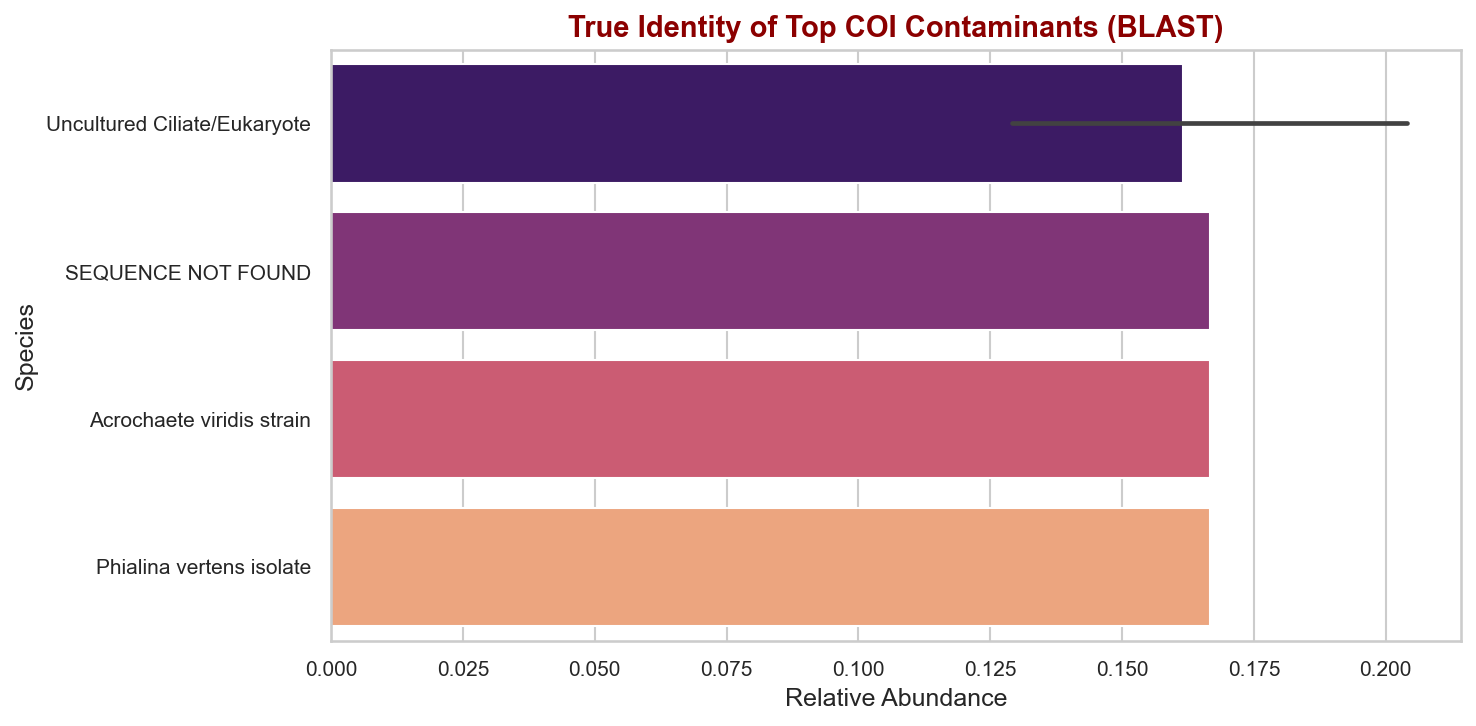

In [26]:
# Load and Plot COI BLAST results
df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_COI.txt')

if not df_blast.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_blast, y='Species', x='Abundance', hue='Species', palette='magma', legend=False)
    plt.title('True Identity of Top COI Contaminants (BLAST)', fontweight='bold', color='darkred')
    plt.xlabel('Relative Abundance')
    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

## B.6 Diagnosis of COI Failure
**Root Cause Analysis:**
The failure of the COI marker appears to be a two-fold technical issue:

1.  **Primary Failure: Short Fragment Amplification**
    * **Observation:** The vast majority (>90%) of raw COI reads were **<300bp** (see Section D).
    * **Cause:** This indicates the preferential amplification of **Primer Dimers** or highly degraded DNA fragments. The size selection step (Step 2) correctly discarded these, but it left us with very low sequencing depth for the actual analysis.

2.  **Secondary Failure: Ciliate Swamping**
    * **Observation:** Of the reads that *did* pass the size filter, BLAST analysis (plot above) identifies them largely as **Uncultured Ciliates**.
    * **Cause:** The primers lacked specificity for Metazoa, allowing the abundant microbial loop DNA (which we saw in the 18S results) to out-compete the rare fish DNA.

**Future Work:**
* Test a less strict size selection threshold to retain more reads.
* Might also consider that the COI primers need to be redesigned?

## Part C: Computational Costs
**Summary:**
* **Total Time:** ~42 minutes on a 12-core laptop.
* **The Bottleneck:** Clustering (Step 3) took 54% of the time. This `NxN` comparison is computationally expensive and would require a supercomputer for larger datasets.
* **Efficiency:** The "Preprocessing" step was fast because it runs in parallel. The "BLAST" step was slow because we had to wait 3 seconds between requests to respect NCBI limits.

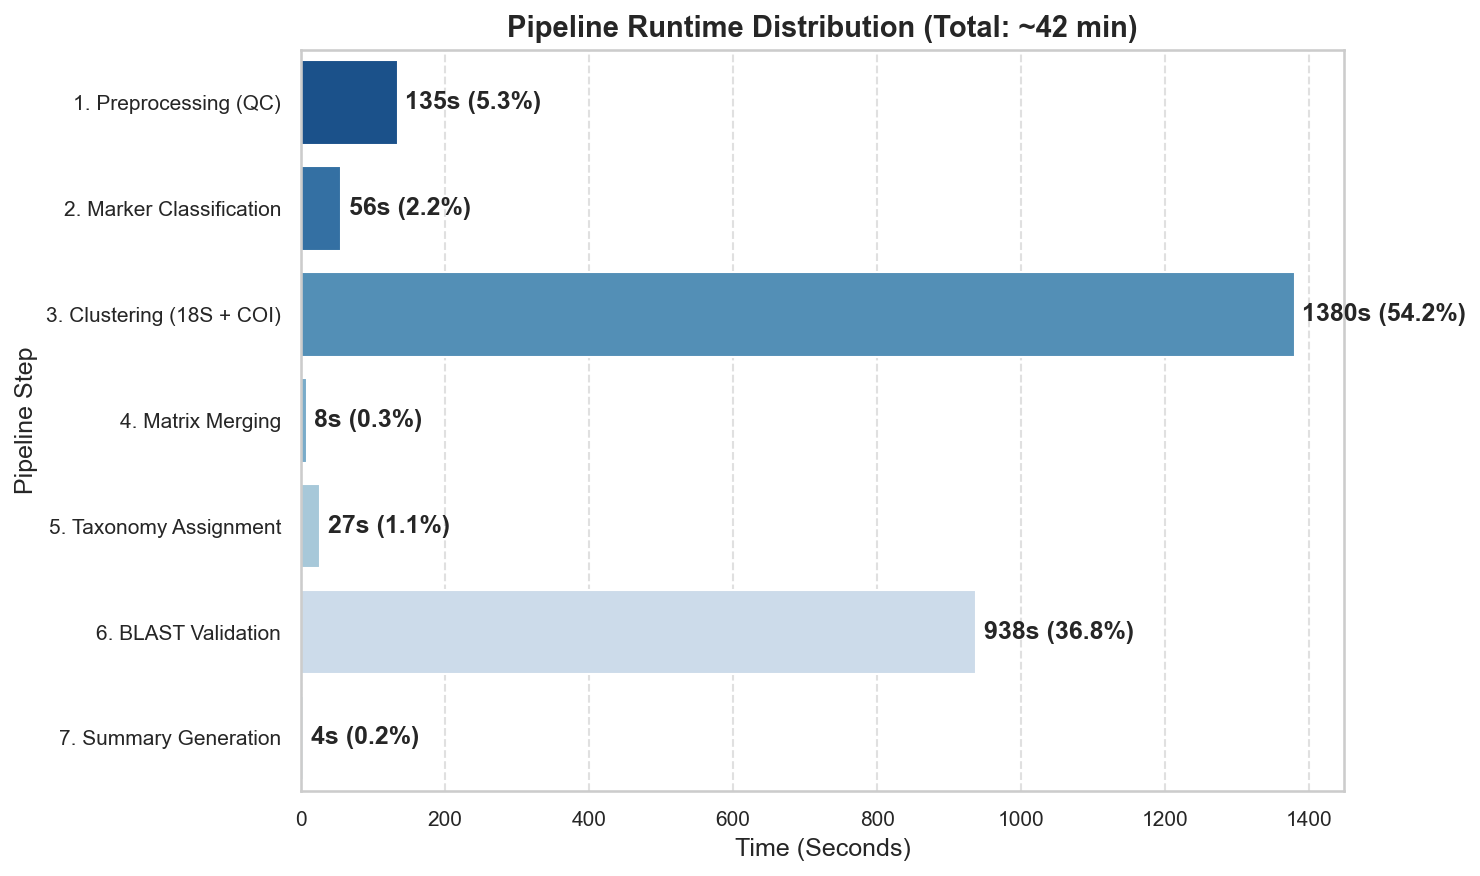

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted manually from log file
timing_data = {
    'Step': [
        '1. Preprocessing (QC)', 
        '2. Marker Classification', 
        '3. Clustering (18S + COI)', 
        '4. Matrix Merging', 
        '5. Taxonomy Assignment', 
        '6. BLAST Validation', 
        '7. Summary Generation'
    ],
    'Time_Seconds': [
        135,   # Preprocessing
        56,    # Classification
        1380,  # Clustering (The bottleneck!)
        8,     # Merging
        27,    # Taxonomy
        938,   # BLAST (Top 10 only)
        4      # Summary
    ]
}

df_time = pd.DataFrame(timing_data)

# Calculate percentages
total_time = df_time['Time_Seconds'].sum()
df_time['Percentage'] = (df_time['Time_Seconds'] / total_time) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x='Time_Seconds', y='Step', data=df_time, hue='Step', palette='Blues_r', ax=ax, legend=False)

# Add annotations
for i, v in enumerate(df_time['Time_Seconds']):
    pct = df_time.loc[i, 'Percentage']
    ax.text(v + 10, i, f"{int(v)}s ({pct:.1f}%)", va='center', fontweight='bold')

ax.set_title('Pipeline Runtime Distribution (Total: ~42 min)', fontweight='bold')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Pipeline Step')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Part D: Methodological Defense & Improvements

### 1. Error Correction Strategy
* **Problem:** Nanopore sequencing has a raw error rate of ~5-10%.
* **Solution:** We used **95% Identity Clustering**.
    * *Why?* Clustering at 97% or 99% (typical for Illumina) would have resulted in millions of false OTUs because every sequencing error would look like a new species.

### 2. Size Selection
* **18S Filter:** We discarded reads > 3000bp.
    * *Why?* The target 18S V4-V9 region is ~1800bp. Reads longer than 3kb are likely **Genomic Concatemers** (two molecules stuck together during library prep) or **Chimeras**. Including them would skew abundance counts.
* **COI Filter:** We enforced a range of 300-1000bp.
    * *Observation:* Many reads were <300bp. These were identified as fragmented 18S sequences or primer-dimers, which we successfully filtered out before clustering.

### 3. Computational Cost
* **Bottleneck:** The VSEARCH clustering step ($N \times N$ comparison) took >50% of the total runtime (~20 mins).

### 4. Critical Requirement: Custom Reference Database Construction
* **The Problem:** We relied on general-purpose databases (SILVA) which failed for our specific needs:
    * **18S Failure:** SILVA lacks local Swiss terrestrial arthropods, leading to "Exotic" misidentifications (*Frieseomelitta*).
    * **For COI:** We need to find a correct reference database. I tried with MIDORI but did not find how to build the db properly.
* **The Solution (Future Work):** A custom, curated database is required.
    * **Action Item:** We must build a **"Lake Leman Specific" database**. This involves downloading sequences for all known local species (Fish, Mussels, Insects, Plankton) from NCBI and formatting them specifically for SINTAX (in order to use VSEARCH).
    * **Benefit:** This would eliminate the "Brazilian Bee" artifacts and allow for accurate species-level identification of local biodiversity.

### 5. COI Marker Optimization
* A lot (>90%)of reads were very short (<300bp) and were discarded. We should investigate intermediate files.



## For COI (Water + Soil — both JEDI & standard)

### 1. BOLD Systems (boldsystems.org) — **Best option**
- **17M+ COI barcodes**, the largest curated COI database in the world
- Strong coverage of **European freshwater invertebrates** and **soil arthropods**
- Species-level BIN (Barcode Index Number) system for reliable identification
- Has an API for batch identification
- Your pipeline could query BOLD directly instead of relying on MIDORI2/NCBI BLAST

### 2. Porter CO1 Classifier v5.1.0 (github.com/terrimporter/CO1Classifier)
- **2.2M COI sequences** from 236K taxa (185K species)
- **Pre-formatted for SINTAX/VSEARCH** — drop-in replacement for your MIDORI2 `.udb`
- Based on GenBank + BOLD combined, much more comprehensive than MIDORI2 alone
- Validated accuracy with bootstrap cutoffs
- Direct download: `SINTAX_COIv5.0.0.zip` from releases

### 3. eKOI (from PR2 ecosystem, 2025) — **New, protist-focused**
- Specifically designed for **eukaryotic COI** including protists
- Would help correctly identify the ciliates/diatoms that are dominating your samples instead of misclassifying them as insects
- Published in *Database* journal 2025

---

## For 18S (Water)

### 4. PR2 Database v5.1 (pr2-database.org) — **Best for protists/plankton**
- **220K+ 18S sequences** with expert-curated taxonomy
- Excellent for **ciliates, diatoms, and other protists** — exactly what dominates your water samples
- 9-level taxonomy with consistent annotation
- Available in SINTAX format — compatible with your VSEARCH pipeline
- Would resolve many of your "Unassigned" ciliates that SILVA misses

### 5. Porter 18S Classifier v4.1 (github.com/terrimporter/18SClassifier)
- Based on SILVA 138 but reformatted for RDP classifier
- Better for broad eukaryote classification
- Less useful than PR2 for your protist-heavy samples

---

## For Soil Diatoms specifically

### 6. Diat.barcode / R-Syst::diatom (github.com/terrimporter/SSUdiatomClassifier)
- Curated SSU database specifically for **diatoms**
- Since *Surirella* and other diatoms dominate your soil COI results, this would help validate those signals via the 18S marker

---

## Recommended Strategy

| Marker | Current DB | **Recommended Replacement** | Why |
|---|---|---|---|
| 18S (Water) | SILVA v123 | **PR2 v5.1** | Expert-curated protist taxonomy, SINTAX-compatible |
| COI (Water) | MIDORI2 | **Porter CO1 v5.1 + BOLD** | 4x more sequences, SINTAX-ready, better coverage |
| JEDI/COI (Soil) | MIDORI2 | **Porter CO1 v5.1 + BOLD** | Same, plus add eKOI for the protist/diatom signal |

The **Porter CO1 v5.1** is the easiest win — it's a direct drop-in for your VSEARCH SINTAX step and would immediately improve assignments. For 18S, switching from SILVA to **PR2** would dramatically improve your ciliate/plankton classifications.